# Football Match Video Analysis with Deep Learning

This notebook demonstrates a complete deep learning pipeline for football (soccer) match video analysis. We start by training a custom YOLOv11 object detection model, then use it to detect players, track them across frames, classify teams by jersey color, track ball possession, and calculate player statistics — all rendered into an annotated output video.


---

## Technologies Used
- **YOLOv26** — object detection (players, ball, referees, goalkeepers)
- **ByteTrack** — multi-object tracking with persistent IDs across frames
- **K-Means clustering** — team classification by jersey color
- **Optical flow** — camera movement compensation using Lucas-Kanade
- **Perspective transform** — mapping pixel positions to real-world field coordinates

---

# Part 1: Model Training (Optional — Google Colab Only)

**NOTE:** This section is for training the YOLOv11 model from scratch. If you already have a trained model (`best.pt`), you can **skip this entire section** and jump directly to Part 2.

This training pipeline is designed to run on **Google Colab** with GPU acceleration. It downloads a custom football dataset from Roboflow, trains a YOLOv11 model for 100 epochs, and saves the best checkpoint.

---

## Why Do We Need Training?

For football analysis, we need to detect **4 specific classes**:
- `player` — field players from both teams
- `goalkeeper` — goalkeepers
- `referee` — match officials
- `ball` — the football itself

**The Challenge:** The ball is extremely small in match footage — averaging only **3.8 × 7.0 pixels** at standard resolution (640px). This makes it nearly impossible for the base model to detect.

**Our Solution:**
1. **Fine-tune YOLOv26** on a custom football dataset (663 annotated images from Roboflow)
2. **Use a larger input size** (1280px instead of 640px) to make the ball ~8×14 pixels
3. **Apply heavy data augmentation** to combat the small dataset size and extreme class imbalance (ball = only 3.6% of annotations)

---

## Step 1: Install Dependencies & Download Dataset

First we install the required packages and download our custom football dataset from Roboflow.

**Dataset Details:**
- **Source:** Roboflow (`football-players-detection-3zvbc`, version 1)
- **Size:** 663 images
- **Classes:** 4 (player, goalkeeper, referee, ball)
- **Format:** YOLOv26 (txt annotations)


In [ ]:
# ---- Install dependencies ----
%pip install ultralytics roboflow

from ultralytics import YOLO
from roboflow import Roboflow
from google.colab import files
from getpass import getpass
import os, glob

# ---- Download dataset from Roboflow ----
ROBOFLOW_API_KEY = getpass("Enter your Roboflow API key: ")

rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace("roboflow-jvuqo").project("football-players-detection-3zvbc")
version = project.version(1)
dataset = version.download("yolov11")

dataset_yaml_path = f"{dataset.location}/data.yaml"
print(f"Dataset ready at: {dataset.location}")

## Step 2: Train the Model

Now we train a YOLOv26x (extra-large) model on our football dataset. We use aggressive data augmentation to compensate for the small dataset size.

### Why Data Augmentation?

Our dataset has **two critical problems:**

1. **Small Dataset Size** — Only 663 images is not enough for deep learning models to generalize well
2. **Severe Class Imbalance** — The ball appears in only 3.6% of annotations, making it extremely hard to detect

**Data augmentation artificially expands the dataset** by creating variations of existing images during training. This helps the model:
- See more diverse examples without collecting more data
- Learn to detect objects at different scales, rotations, and lighting conditions
- Reduce overfitting (memorizing the training data instead of learning general patterns)

### Augmentation Techniques We Use:

| Technique | Value | Purpose |
|-----------|-------|---------|
| **Mosaic** | 1.0 | Combines 4 images into one — ball appears at different scales |
| **Copy-Paste** | 0.3 | Copies ball/player annotations between images — fights class imbalance |
| **Mixup** | 0.15 | Blends 2 images together — mild regularization |
| **Scale** | 0.5 | Random zoom in/out — sometimes makes ball bigger |
| **Rotation** | ±5° | Random rotation — handles camera angles |
| **Flip LR** | 0.5 | Horizontal flip 50% of the time — doubles effective dataset |
| **HSV Jitter** | Various | Changes hue/saturation/brightness — handles different lighting |

### Critical Parameter: Image Size (imgsz)

At the default size of 640px, the ball is only **~4×7 pixels** — too small to detect reliably.  
At 1280px, the ball becomes **~8×14 pixels** — the minimum size for detection to work.

**Trade-off:** Larger images use 4× more GPU memory, so we reduce batch size from 8 to 4.

In [ ]:
# ---- Train the model ----
model = YOLO("yolo26x.pt")

results = model.train(
    data=dataset_yaml_path,

    # --- Training schedule ---
    epochs=150,
    patience=30,

    # --- Image & batch ---
    imgsz=1280,
    batch=16,                # A100 40GB handles 16 at 1280 with yolo11x
    workers=8,

    # --- Optimizer ---
    optimizer="AdamW",
    lr0=0.0005,              # lower LR to prevent overfitting on 372 images
    lrf=0.01,                # final LR = 0.000005
    weight_decay=0.05,       # strong regularization for small dataset
    warmup_epochs=5,         # longer warmup for larger batch size

    # --- Augmentation ---
    augment=True,
    mosaic=1.0,
    mixup=0.1,
    copy_paste=0.0,          # does nothing without segmentation masks
    degrees=10.0,
    scale=0.4,               # max 40% — more will make the ball undetectable
    shear=2.0,
    perspective=0.0003,
    fliplr=0.5,
    flipud=0.0,
    hsv_h=0.015,
    hsv_s=0.5,
    hsv_v=0.3,
    erasing=0.3,             # random erasing — forces learning redundant features

    # --- Mosaic scheduling ---
    close_mosaic=15,         # disable mosaic last 15 epochs for fine-tuning

    # --- Output ---
    plots=True,
    save=True,
    project="runs/detect",
    name="football_v2",
)

print("Training complete!")
print("Check runs/detect/football_v2/ for results.png and confusion_matrix.png")

NameError: name 'YOLO' is not defined

## Step 3: Download the Trained Model

After training completes, download the `best.pt` checkpoint from Colab to your local machine. This is the model you'll use for inference in the rest of the notebook.

In [ ]:
# ---- Download the trained model ----
best_model_path = "runs/detect/football_v2/weights/best.pt"

if os.path.exists(best_model_path):
    print(f"Best model found at: {best_model_path}")
    print("Downloading best.pt...")
    files.download(best_model_path)
else:
    # Training might have auto-incremented the folder name
    all_weights = glob.glob("runs/detect/football_v2*/weights/best.pt")
    if all_weights:
        latest = sorted(all_weights)[-1]
        print(f"Found model at: {latest}")
        files.download(latest)
    else:
        print("No trained model found. Check the training output above for errors.")

---

---

# Part 2: Setup & Installation

**If you trained the model in Part 1**, skip the training cells above and start here.

This section installs the required packages for the full pipeline (detection, tracking, team classification, and visualization).

## Install Required Packages

We need two main packages:
- **ultralytics** — YOLOv26 object detection framework
- **supervision** — ByteTrack multi-object tracking and video utilities

In [32]:
%pip install ultralytics
%pip install supervision

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Import Libraries

Import all required libraries:
- **NumPy** — numerical operations and array handling
- **OpenCV (cv2)** — video/image processing and perspective transforms
- **YOLO** — YOLOv11 object detection model
- **supervision** — ByteTrack tracking and video utilities
- **scikit-learn** — K-Means clustering for team classification
- **pandas** — data handling for ball position interpolation
- **pickle** — caching detection results to avoid re-computation

In [ ]:
# numpy - for arrays and math operations
import numpy as np

# os - for file and directory operations
import os

# matplotlib - to display images
import matplotlib.pyplot as plt

# YOLO - the detection model
from ultralytics import YOLO

# supervision - for ByteTrack tracking
import supervision as sv

# pickle - to save and load cached results
import pickle

# cv2 - OpenCV for video processing
import cv2

# pandas - to interpolate missing ball positions
import pandas as pd

# KMeans - to cluster players into teams by jersey color
from sklearn.cluster import KMeans

## Configuration & File Paths

Set up all paths, models, and parameters for the pipeline:

1. **Video & Models**
   - Input video to analyze
   - Base model (pre-training) and trained model (fine-tuned)

2. **Cache Paths**
   - Tracking results are cached to `.pkl` files to avoid re-running expensive detection
   - Camera movement is also cached

3. **Perspective Transform Points**
   - `PIXEL_VERTICES` — 4 points in the video frame (corners of the field)
   - `TARGET_VERTICES` — corresponding points in real-world coordinates (meters)
   - These create a mapping from camera view → top-down field view
   - Used to calculate real-world speed and distance

**Field Dimensions:** 68m × 23.32m (standard football pitch proportions)

In [ ]:
VIDEO_PATH = "573e61_0.mp4"

BASE_MODEL_PATH = "yolo11m.pt"
TRAINED_MODEL_PATH = "Trained_Models/best11022025_V2.pt"

_video_name = os.path.splitext(os.path.basename(VIDEO_PATH))[0]
TRACK_PATH = f"runs/output_videos/{_video_name}_tracks.pkl"
CAMERA_STUB_PATH = f"runs/output_videos/{_video_name}_camera_movement_stub.pkl"
OUTPUT_VIDEO_PATH = f"runs/output_videos/{_video_name}_full_pipeline.avi"

PIXEL_VERTICES = np.array([  # Playing field points
    [110, 1035],
    [265, 275],
    [910, 260],
    [1640, 915]
])

COURT_WIDTH = 68
COURT_LENGTH = 23.32

TARGET_VERTICES = np.array([ # Playing field Size
    [0, COURT_WIDTH],
    [0, 0],
    [COURT_LENGTH, 0],
    [COURT_LENGTH, COURT_WIDTH]
])

os.makedirs("runs/output_videos", exist_ok=True)
print(f"Video: {VIDEO_PATH}")
print(f"Base model: {BASE_MODEL_PATH}")
print(f"Trained model: {TRAINED_MODEL_PATH}")
print(f"Tracks: {TRACK_PATH}")
print(f"Output video: {OUTPUT_VIDEO_PATH}")

Video: 573e61_0.mp4
Base model: yolo11m.pt
Trained model: Trained_Models/best11022025_V2.pt
Tracks: runs/output_videos/573e61_0_tracks.pkl
Output video: runs/output_videos/573e61_0_full_pipeline.avi


---

---

# Part 3: Model Comparison (Before vs After Training)

This section compares the base YOLOv11 model (trained on COCO) with our fine-tuned model. We run both models on the same frame and visualize the difference in detection quality.

**Expected Difference:**
- **Base model** — may detect generic "person" class, but won't distinguish players/goalkeepers/referees, and will likely miss the ball entirely
- **Fine-tuned model** — should detect all 4 classes accurately: players, goalkeepers, referees, and ball

---

# Model Before Training
Here we load the base YOLOv11 model (before any fine-tuning) and run it on a single frame from the match video. This lets us see how well the generic model detects football players without any special training.

In [35]:
PLAYER_DETECTION_MODEL = YOLO(BASE_MODEL_PATH)

Run detection on a single frame using the base model. We get the first frame, run YOLO + ByteTrack on it, and draw bounding boxes with labels and tracking traces. This shows what the generic model can see.


0: 384x640 21 persons, 1 tv, 207.6ms
Speed: 7.2ms preprocess, 207.6ms inference, 14.2ms postprocess per image at shape (1, 3, 384, 640)


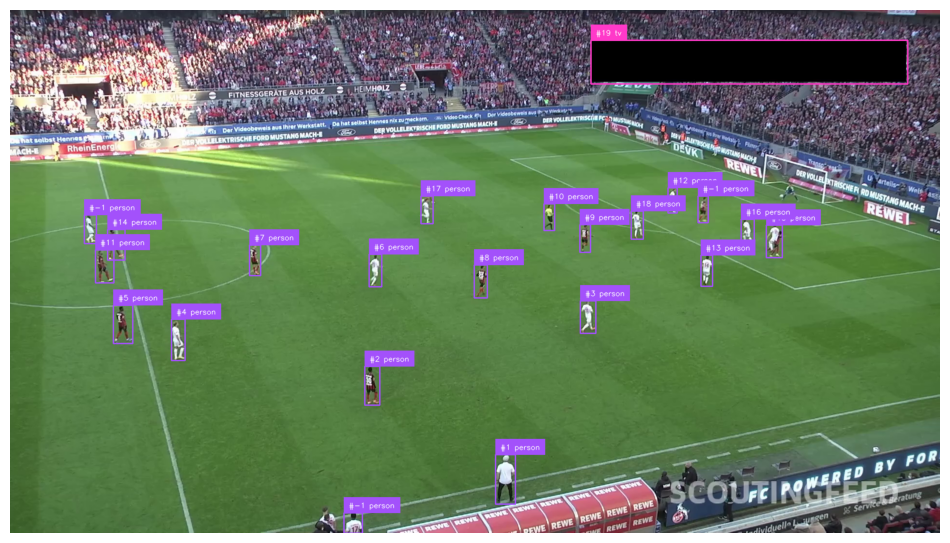

In [36]:
frame_generator = sv.get_video_frames_generator(VIDEO_PATH)
frame = next(frame_generator)

tracker = sv.ByteTrack()
bounding_box = sv.BoxAnnotator()
label = sv.LabelAnnotator()
trace_annotator = sv.TraceAnnotator()

results = PLAYER_DETECTION_MODEL(frame)[0]
detections = sv.Detections.from_ultralytics(results)

tracked_detections = tracker.update_with_detections(detections)

labels = [
    f"#{tracker_id} {class_name}"
    for class_name, tracker_id
    in zip(detections.data["class_name"], detections.tracker_id)
]

annotated_frame = bounding_box.annotate(frame.copy(), detections=detections)
annotated_frame = label.annotate(annotated_frame, detections=detections, labels=labels)
annotated_frame = trace_annotator.annotate(annotated_frame, detections=detections)

sv.plot_image(annotated_frame)

--- 

# Model After Training
Now we load our fine-tuned model and test it on the same frame. This model was trained on a custom football dataset with 4 classes: player, goalkeeper, referee, and ball. Compare the results with the base model above — you should see much better detections.

In [37]:
TRAINED_DETECTION_MODEL = YOLO(TRAINED_MODEL_PATH)

Run the same detection on the same frame, but now using our trained model. Compare this image with the one above to see how much training improved the results.


0: 736x1280 1 ball, 1 goalkeeper, 20 players, 2 referees, 1193.9ms
Speed: 6.1ms preprocess, 1193.9ms inference, 0.9ms postprocess per image at shape (1, 3, 736, 1280)


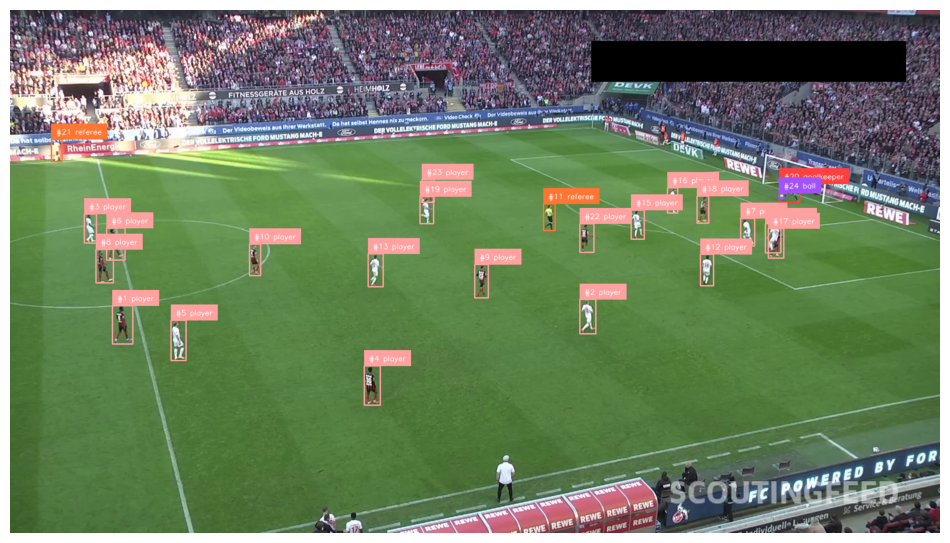

In [38]:
frame_generator = sv.get_video_frames_generator(VIDEO_PATH)
frame = next(frame_generator)

tracker = sv.ByteTrack()
bounding_box = sv.BoxAnnotator()
label = sv.LabelAnnotator()
trace_annotator = sv.TraceAnnotator()

results = TRAINED_DETECTION_MODEL(frame)[0]
detections = sv.Detections.from_ultralytics(results)

tracked_detections = tracker.update_with_detections(detections)

labels = [
    f"#{tracker_id} {class_name}"
    for class_name, tracker_id
    in zip(detections.data["class_name"], detections.tracker_id)
]

annotated_frame = bounding_box.annotate(frame.copy(), detections=detections)
annotated_frame = label.annotate(annotated_frame, detections=detections, labels=labels)
annotated_frame = trace_annotator.annotate(annotated_frame, detections=detections)

sv.plot_image(annotated_frame)

---

# Helper Functions
Below are all the utility functions we need for the pipeline. This includes functions for reading and writing video files, running detection and tracking, and drawing visual annotations on video frames.

### Video I/O
`read_video()` reads all frames from a video file into a list of images. `save_frames()` writes a list of frames back to an AVI video file at 24 fps.

In [ ]:
# reads video and returns all frames as a list
def read_video(PATH):
    cap = cv2.VideoCapture(PATH)
    frames = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frames.append(frame)
    cap.release()
    return frames

# writes frames to video file
def save_frames(output_frames, output_folder):
    fourcc = cv2.VideoWriter_fourcc(*'XVID')
    out = cv2.VideoWriter(output_folder, fourcc, 24.0, (output_frames[0].shape[1], output_frames[0].shape[0]))
    for frame in output_frames:
        out.write(frame)
    out.release()

---

## Object Detection & Tracking Functions
These functions handle the core detection and tracking:
- `detect_frames()` — runs YOLO on all frames in batches of 20 for speed
- `get_object_tracks()` — uses ByteTrack to give each detected object a unique ID that stays the same across frames. Goalkeepers are merged into the player class. Results are cached to a `.pkl` file so we don't need to re-run detection every time.

In [ ]:
tracker = sv.ByteTrack()

# runs YOLO detection on all frames in batches of 20
def detect_frames(frames):
    batch_size = 20
    detections = []
    for i in range(0, len(frames), batch_size):
        detections_batch = TRAINED_DETECTION_MODEL.predict(frames[i:i+batch_size], conf=0.1)
        detections += detections_batch
    return detections


# detects objects and assigns tracking IDs that persist across frames
# saves results to file to avoid re-running detection
def get_object_tracks(frames, read_from_disk=False, track_path=None):
    if read_from_disk and track_path is not None and os.path.exists(track_path):
        with open(track_path, "rb") as f:
            tracked_objects = pickle.load(f)
            return tracked_objects

    detections = detect_frames(frames)
    tracked_objects = {
        "players": [],
        "referees": [],
        "ball": []
    }

    for frame_num, detections in enumerate(detections):
        cls_names = detections.names
        cls_names_inv = {v: k for k, v in cls_names.items()}

        detections_supervision = sv.Detections.from_ultralytics(detections)

        # merge goalkeepers into player class
        for obj_id, class_id in enumerate(detections_supervision.class_id):
            if cls_names[class_id] == "goalkeeper":
                detections_supervision.class_id[obj_id] = cls_names_inv["player"]

        detection_with_tracks = tracker.update_with_detections(detections_supervision)

        tracked_objects["players"].append({})
        tracked_objects["referees"].append({})
        tracked_objects["ball"].append({})

        for frame_detection in detection_with_tracks:
            bbox = frame_detection[0].tolist()
            class_id = frame_detection[3]
            track_id = frame_detection[4]

            if class_id == cls_names_inv["player"]:
                tracked_objects["players"][frame_num][track_id] = {
                    "bbox": bbox,
                    "class_id": class_id,
                    "frame": frame_num
                }
            elif class_id == cls_names_inv["referee"]:
                tracked_objects["referees"][frame_num][track_id] = {
                    "bbox": bbox,
                    "class_id": class_id,
                    "frame": frame_num
                }

        ball_class_id = cls_names_inv["ball"]
        ball_mask = detections_supervision.class_id == ball_class_id

        # keep only highest confidence ball detection
        if ball_mask.any():
            ball_detections = detections_supervision[ball_mask]
            best_idx = ball_detections.confidence.argmax()
            best_bbox = ball_detections.xyxy[best_idx].tolist()
            tracked_objects["ball"][frame_num][1] = {"bbox": best_bbox}

        if track_path is not None:
            with open(track_path, "wb") as f:
                pickle.dump(tracked_objects, f)

    return tracked_objects

## Drawing & Annotation Functions
These helper functions handle all the visual output: colored ellipses under players, triangles above the ball holder, track ID labels, and distance measurements. The `draw_annotations()` function puts it all together for each frame.

In [ ]:
# returns center point of bounding box
def get_center_bbox(bbox):
    x1, y1, x2, y2 = bbox
    return int((x1 + x2) / 2), int((y1 + y2) / 2)


# returns width of bounding box
def get_width_bbox(bbox):
    return bbox[2] - bbox[0]


# converts color to BGR format
def _as_bgr(color, default=(0, 0, 255)):
    if color is None:
        return default
    try:
        return tuple(int(c) for c in color)
    except Exception:
        return default


# draws ellipse under player with track ID number
# adds yellow ring if player has the ball
def draw_ellipse(frame, bbox, color, track_id, has_ball=False):
    x1, y1, x2, y2 = map(int, bbox)
    x_center = (x1 + x2) // 2
    y_bottom = y2
    width = max(18, x2 - x1)

    main_color = _as_bgr(color)
    axes = (max(width // 2, 12), max(int(width * 0.20), 8))

    # draw shadow
    overlay = frame.copy()
    cv2.ellipse(overlay, (x_center, y_bottom), axes,
                0, -40, 220, (0, 0, 0), -1, cv2.LINE_AA)
    cv2.addWeighted(overlay, 0.22, frame, 0.78, 0, frame)

    # draw main ellipse
    cv2.ellipse(frame, (x_center, y_bottom), axes,
                0, -40, 220, main_color, 3, cv2.LINE_AA)

    # add ring for ball possession
    if has_ball:
        cv2.ellipse(frame, (x_center, y_bottom),
                    (axes[0] + 5, axes[1] + 4),
                    0, -40, 220, (0, 215, 255), 2, cv2.LINE_AA)

    # draw track ID
    if track_id is not None:
        label = str(track_id)
        (text_w, text_h), _ = cv2.getTextSize(
            label, cv2.FONT_HERSHEY_SIMPLEX, 0.55, 2
        )
        pad = 8
        box_w = text_w + 2 * pad
        box_h = text_h + 8
        x1_rect = x_center - box_w // 2
        y1_rect = y_bottom + 10
        x2_rect = x1_rect + box_w
        y2_rect = y1_rect + box_h

        cv2.rectangle(frame, (x1_rect, y1_rect), (x2_rect, y2_rect), (0, 0, 0), -1)
        cv2.rectangle(frame, (x1_rect + 1, y1_rect + 1),
                      (x2_rect - 1, y2_rect - 1), main_color, -1)
        cv2.putText(frame, label, (x1_rect + pad, y2_rect - 6),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, (20, 20, 20), 2, cv2.LINE_AA)

    return frame


# calculates distance between two points
def measure_distance(p1, p2):
    return ((p1[0] - p2[0]) ** 2 + (p1[1] - p2[1]) ** 2) ** 0.5


# returns x and y distance components
def measure_xy_distance(p1, p2):
    return p1[0] - p2[0], p1[1] - p2[1]


# returns foot position (bottom center of bbox)
def get_foot_position(bbox):
    x1, y1, x2, y2 = bbox
    return int((x1 + x2) / 2), int(y2)


# draws triangle marker
def draw_triangle(frame, bbox, color, y_offset=0, size=11):
    x, _ = get_center_bbox(bbox)
    tip_y = max(5, int(bbox[1]) + y_offset)

    triangle_points = np.array([
        [x, tip_y],
        [x - size, tip_y - (2 * size)],
        [x + size, tip_y - (2 * size)],
    ])

    color = _as_bgr(color, default=(255, 255, 255))
    cv2.drawContours(frame, [triangle_points], 0, color, cv2.FILLED)
    cv2.drawContours(frame, [triangle_points], 0, (0, 0, 0), 2)
    return frame


# draws all annotations - players, ball, referees
def draw_annotations(video_frames, tracked_objects):
    output_video_frames = []

    for frame_num, frame in enumerate(video_frames):
        frame = frame.copy()

        player_dict = tracked_objects["players"][frame_num]
        ball_dict = tracked_objects["ball"][frame_num]
        referee_dict = tracked_objects["referees"][frame_num]

        # draw players
        for track_id, player in player_dict.items():
            color = player.get('team_color', (0, 0, 255))
            has_ball = player.get('has_ball', False)
            frame = draw_ellipse(frame, player["bbox"], color, track_id, has_ball=has_ball)

            if has_ball:
                frame = draw_triangle(frame, player["bbox"], (0, 215, 255), y_offset=-12, size=8)

        # draw referees
        for track_id, referee in referee_dict.items():
            frame = draw_ellipse(frame, referee["bbox"], (235, 235, 0), track_id, has_ball=False)

        # draw ball
        for _, ball in ball_dict.items():
            frame = draw_triangle(frame, ball["bbox"], (255, 255, 255), y_offset=2, size=8)

        output_video_frames.append(frame)

    return output_video_frames

### Run Detection, Tracking & Draw Annotations
Read the video, run object tracking (or load cached results from disk), and draw annotations on every frame.

In [42]:

video_frames = read_video(VIDEO_PATH)
tracked_objects = get_object_tracks(video_frames, read_from_disk=True, track_path=TRACK_PATH)
output_video_frames = draw_annotations(video_frames, tracked_objects)


0: 736x1280 1 ball, 1 goalkeeper, 20 players, 2 referees, 1341.0ms
1: 736x1280 1 ball, 1 goalkeeper, 20 players, 2 referees, 1341.0ms
2: 736x1280 1 goalkeeper, 20 players, 2 referees, 1341.0ms
3: 736x1280 1 goalkeeper, 20 players, 2 referees, 1341.0ms
4: 736x1280 1 goalkeeper, 20 players, 2 referees, 1341.0ms
5: 736x1280 1 goalkeeper, 20 players, 2 referees, 1341.0ms
6: 736x1280 1 goalkeeper, 20 players, 2 referees, 1341.0ms
7: 736x1280 1 goalkeeper, 20 players, 2 referees, 1341.0ms
8: 736x1280 1 goalkeeper, 20 players, 2 referees, 1341.0ms
9: 736x1280 1 goalkeeper, 20 players, 2 referees, 1341.0ms
10: 736x1280 1 goalkeeper, 21 players, 2 referees, 1341.0ms
11: 736x1280 1 goalkeeper, 22 players, 2 referees, 1341.0ms
12: 736x1280 1 goalkeeper, 20 players, 2 referees, 1341.0ms
13: 736x1280 1 goalkeeper, 20 players, 2 referees, 1341.0ms
14: 736x1280 1 ball, 21 players, 2 referees, 1341.0ms
15: 736x1280 21 players, 2 referees, 1341.0ms
16: 736x1280 21 players, 2 referees, 1341.0ms
17: 736

---

---

# Team Classification

In this section we determine which team each player belongs to based on **jersey color**.

## The Algorithm (Two-Stage K-Means Clustering)

### Stage 1: Extract Jersey Color (Per Player)

For each player:
1. Crop the player image from the bounding box
2. Take only the **top half** (where the jersey is visible)
3. **Remove side margins** (20% on each side) to exclude arms/background
4. Convert to **LAB color space** (perceptually uniform — better for color clustering than RGB)
5. Run **K-Means (k=2)** to separate foreground (jersey) from background
6. Identify the background cluster by checking corner pixels (usually background)
7. Extract the **average jersey color** (the non-background cluster)

### Stage 2: Group Players into Teams

After extracting jersey colors for all players:
1. Run **K-Means (k=2)** on all jersey colors in LAB space
2. The two clusters represent the two teams
3. Each player is assigned to their cluster (team 1 or team 2)
4. The average color of each cluster becomes the team color (used for visualization)

**Why LAB color space?**  
LAB is designed to match human perception of color differences. Two colors that look similar to humans are close in LAB space. This makes K-Means more reliable for jersey color clustering than RGB.

**Why top half only?**  
Shorts and socks can have different colors than the jersey, and legs/feet are often the same color across teams (skin tone). Using only the top half focuses on the most distinctive feature: the jersey.

---

In [43]:
os.makedirs("runs/cropped_players", exist_ok=True)
for track_id, player in tracked_objects['players'][1].items():
    bbox = player['bbox']
    frame = video_frames[1]
    x1, y1, x2, y2 = map(int, bbox)
    cropped_image = frame[y1:y2, x1:x2]
    cv2.imwrite(f"runs/cropped_players/player_{track_id}_cropped.jpg", cropped_image)
    break

Here we look at a cropped player image. This is what the team classifier will work with — it needs to figure out the jersey color from this crop.

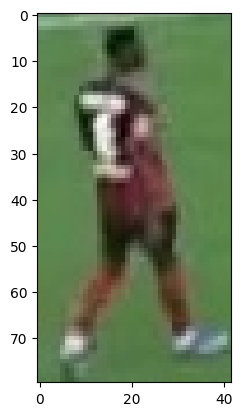

In [44]:
image_path = "runs/cropped_players/player_1_cropped.jpg"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image)
plt.show()

We only use the **top half** of the player image for team classification. The top half shows the jersey, while the bottom half shows shorts and legs which are less useful for telling teams apart.

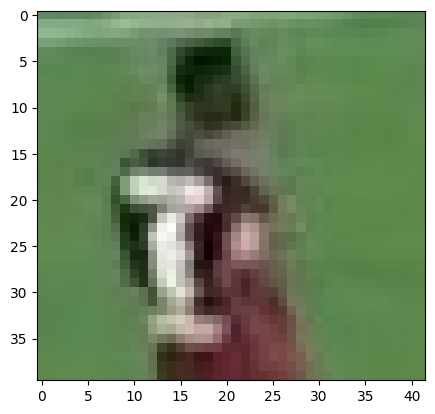

In [45]:
top_half_image = image[0:image.shape[0]//2, 0:image.shape[1]]
plt.imshow(top_half_image)
plt.show()

### TeamAssigner Class
This class does the team classification in two steps:
1. **Per player** — crop the jersey area, run K-Means (k=2) to separate jersey pixels from background, then extract the average jersey color
2. **All players** — run K-Means (k=2) on all jersey colors to split players into 2 teams

Once a player gets a team, the result is cached so we don't re-compute it every frame.

In [ ]:
# assigns players to teams based on jersey color
class TeamAssigner:
    def __init__(self):
        self.team_colors = {}
        self.player_team_dict = {}
        self.kmeans = None

    # extracts jersey color from player crop
    # uses top half only where jersey is visible
    def _get_jersey_color(self, frame, bbox):
        image = frame[int(bbox[1]):int(bbox[3]), int(bbox[0]):int(bbox[2])]
        top_half = image[0:image.shape[0] // 2, :]

        h, w = top_half.shape[:2]
        margin = int(w * 0.2)
        if margin > 0 and w - 2 * margin > 5:
            top_half = top_half[:, margin:w - margin]

        # convert to LAB for better clustering
        top_lab = cv2.cvtColor(top_half, cv2.COLOR_BGR2LAB)
        pixels_lab = top_lab.reshape(-1, 3).astype(np.float64)
        pixels_bgr = top_half.reshape(-1, 3)

        # separate jersey from background
        km = KMeans(n_clusters=2, init="k-means++", n_init=1)
        km.fit(pixels_lab)

        labels = km.labels_.reshape(top_half.shape[0], top_half.shape[1])
        corners = [labels[0, 0], labels[0, -1], labels[-1, 0], labels[-1, -1]]
        bg_cluster = max(set(corners), key=corners.count)
        player_cluster = 1 - bg_cluster

        jersey_bgr = pixels_bgr[km.labels_ == player_cluster].mean(axis=0)
        jersey_lab = pixels_lab[km.labels_ == player_cluster].mean(axis=0)
        return jersey_bgr, jersey_lab

    # clusters all players into 2 teams
    def assign_team_colors(self, frame, player_detections):
        bgr_colors = []
        lab_colors = []
        for _, det in player_detections.items():
            bgr, lab = self._get_jersey_color(frame, det["bbox"])
            bgr_colors.append(bgr)
            lab_colors.append(lab)

        # cluster into 2 teams
        self.kmeans = KMeans(n_clusters=2, init="k-means++", n_init=20)
        self.kmeans.fit(lab_colors)

        # calculate average color per team
        for team_idx in range(2):
            mask = self.kmeans.labels_ == team_idx
            self.team_colors[team_idx + 1] = np.array(bgr_colors)[mask].mean(axis=0)

    # returns team ID (1 or 2) for a player
    def get_player_team(self, frame, bbox, player_id):
        if player_id in self.player_team_dict:
            return self.player_team_dict[player_id]

        _, lab = self._get_jersey_color(frame, bbox)
        team_id = self.kmeans.predict(lab.reshape(1, -1))[0] + 1

        self.player_team_dict[player_id] = team_id
        return team_id

Run team assignment on all frames. For each player in each frame, we find their team and store the team ID and color in the tracking data. Then we re-draw the annotations with team colors.

In [47]:
video_frames = read_video(VIDEO_PATH)
tracked_objects = get_object_tracks(video_frames, read_from_disk=True, track_path=TRACK_PATH)

team_assigner = TeamAssigner()
team_assigner.assign_team_colors(video_frames[0], tracked_objects['players'][0])

for frame_num, player_track in enumerate(tracked_objects['players']):
    for player_id, track in player_track.items():
        team = team_assigner.get_player_team(video_frames[frame_num], track['bbox'], player_id)
        tracked_objects['players'][frame_num][player_id]['team'] = team
        tracked_objects['players'][frame_num][player_id]['team_color'] = team_assigner.team_colors[team]

output_video_frames = draw_annotations(video_frames, tracked_objects)

---

---

# Ball Tracking & Possession Assignment

This section handles two critical tasks:

## 1. Ball Position Interpolation

**Problem:** The ball detector doesn't detect the ball in every frame (detection confidence varies, ball may be occluded, or too small).

**Solution:** Linear interpolation fills in missing ball positions using pandas DataFrame interpolation:
- Convert ball positions to DataFrame
- Use `.interpolate()` to fill gaps with linear estimates
- Use `.bfill()` (backward fill) to handle missing values at the start

This creates a **smooth ball trajectory** even when detection is intermittent.

## 2. Ball Possession Assignment

**Problem:** Which player has the ball at each moment?

**Solution:** Distance-based assignment:
- For each frame, measure the distance from the ball to each player's feet
- Assign the ball to the **closest player within 50 pixels**
- Track which team has possession over time

This data is used for:
- Drawing a triangle above the ball holder
- Drawing the team possession bar (% of time each team controls the ball)
- Calculating per-player possession stats

---

In [ ]:
# fills in missing ball positions
# detector doesn't see ball every frame so we guess where it was
def interpolate_ball_position(ball_position):
    ball_position = [x.get(1,{}).get('bbox',[]) for x in ball_position]
    df_ball_position = pd.DataFrame(ball_position, columns=['x1', 'y1', 'x2', 'y2'])
    df_ball_position = df_ball_position.interpolate()
    df_ball_position = df_ball_position.bfill()
    ball_position = [{1: {"bbox":x}} for x in df_ball_position.to_numpy().tolist()]
    return ball_position

Run ball interpolation and team assignment together. The interpolated ball positions fill in the frames where the detector missed the ball, giving us a smooth ball trajectory.

In [49]:
video_frames = read_video(VIDEO_PATH)
tracked_objects = get_object_tracks(video_frames, read_from_disk=True, track_path=TRACK_PATH)

tracked_objects["ball"] = interpolate_ball_position(tracked_objects["ball"])

team_assigner = TeamAssigner()
team_assigner.assign_team_colors(video_frames[0], tracked_objects['players'][0])
for frame_num, player_track in enumerate(tracked_objects['players']):
        for player_id, track in player_track.items():
            team = team_assigner.get_player_team(video_frames[frame_num],
                                                 track['bbox'],
                                                 player_id)
            tracked_objects['players'][frame_num][player_id]['team'] = team
            tracked_objects['players'][frame_num][player_id]['team_color'] = team_assigner.team_colors[team]

output_video_frames = draw_annotations(video_frames, tracked_objects)

---

## Ball Possession Functions
These functions figure out which player has the ball at each frame (the closest player within 50 pixels), and calculate the total possession percentage for each team. A possession bar is drawn at the bottom of each frame.

In [ ]:
max_player_ball_distance = 50


# finds which player is closest to the ball
# returns their ID or -1 if no one is close enough
def assign_ball_to_player(players, ball_bbox):
    ball_pos = get_center_bbox(ball_bbox)

    assigned_player = -1
    min_distance = max_player_ball_distance

    for player_id, player in players.items():
        bbox = player['bbox']

        # check both feet, use whichever is closer
        dist_left = measure_distance((bbox[0], bbox[3]), ball_pos)
        dist_right = measure_distance((bbox[2], bbox[3]), ball_pos)
        distance = min(dist_left, dist_right)

        if distance < min_distance:
            min_distance = distance
            assigned_player = player_id

    return assigned_player


# calculates how much each team had the ball (in %)
def calculate_team_possession(tracked_objects):
    team_1_frames = 0
    team_2_frames = 0

    for frame_num, player_track in enumerate(tracked_objects['players']):
        for _, info in player_track.items():
            if info.get('has_ball', False) and 'team' in info:
                if info['team'] == 1:
                    team_1_frames += 1
                elif info['team'] == 2:
                    team_2_frames += 1

    total = team_1_frames + team_2_frames
    if total == 0:
        return 50.0, 50.0

    t1_pct = round(team_1_frames / total * 100, 1)
    t2_pct = round(team_2_frames / total * 100, 1)
    return t1_pct, t2_pct


# draws possession bar at bottom of screen
def draw_team_possession(frame, team_1_pct, team_2_pct, team_colors_bgr):
    h, w = frame.shape[:2]

    # make sure percentages add up to 100
    t1 = float(np.clip(team_1_pct, 0, 100))
    t2 = float(np.clip(team_2_pct, 0, 100))
    if t1 + t2 == 0:
        t1, t2 = 50.0, 50.0
    else:
        scale = 100.0 / (t1 + t2)
        t1 *= scale
        t2 *= scale

    color1 = tuple(int(c) for c in team_colors_bgr.get(1, (40, 120, 240)))
    color2 = tuple(int(c) for c in team_colors_bgr.get(2, (60, 220, 120)))
    font = cv2.FONT_HERSHEY_DUPLEX

    panel_w = min(620, w - 32)
    panel_h = 66
    panel_x = (w - panel_w) // 2
    panel_y = h - panel_h - 12

    # dark background
    overlay = frame.copy()
    cv2.rectangle(overlay, (panel_x, panel_y),
                  (panel_x + panel_w, panel_y + panel_h),
                  (20, 20, 20), -1)
    cv2.addWeighted(overlay, 0.58, frame, 0.42, 0, frame)

    bar_x = panel_x + 14
    bar_y = panel_y + 30
    bar_w = panel_w - 28
    bar_h = 20

    # gray bar
    cv2.rectangle(frame, (bar_x, bar_y), (bar_x + bar_w, bar_y + bar_h), (55, 55, 55), -1)

    # colored parts for each team
    split_x = bar_x + int((t1 / 100.0) * bar_w)
    cv2.rectangle(frame, (bar_x, bar_y), (split_x, bar_y + bar_h), color1, -1)
    cv2.rectangle(frame, (split_x, bar_y), (bar_x + bar_w, bar_y + bar_h), color2, -1)
    cv2.rectangle(frame, (bar_x, bar_y), (bar_x + bar_w, bar_y + bar_h), (235, 235, 235), 1)
    cv2.line(frame, (split_x, bar_y), (split_x, bar_y + bar_h), (255, 255, 255), 1)

    # percentage text
    left_text = f"Team 1  {t1:.1f}%"
    right_text = f"{t2:.1f}%  Team 2"

    cv2.putText(frame, left_text, (bar_x, panel_y + 21),
                font, 0.58, (255, 255, 255), 1, cv2.LINE_AA)

    (rt_w, _), _ = cv2.getTextSize(right_text, font, 0.58, 1)
    cv2.putText(frame, right_text, (bar_x + bar_w - rt_w, panel_y + 21),
                font, 0.58, (255, 255, 255), 1, cv2.LINE_AA)

    return frame

In [ ]:
# adds foot position to each tracked object
# needed for calculating distances
def add_position_to_tracks(tracks):
    for object, object_tracks in tracks.items():
        for frame_num, track in enumerate(object_tracks):
            for track_id, track_info in track.items():
                bbox = track_info['bbox']
                position = get_foot_position(bbox)
                tracks[object][frame_num][track_id]['position'] = position

---
## Camera Movement & Perspective Transform
To get accurate real-world positions, we need two things:
1. **Camera movement compensation** — the camera pans during the match, so we use optical flow (Lucas-Kanade) on the field edges to estimate camera movement and adjust player positions
2. **Perspective transform** — we map the camera view to a top-down field view using 4 reference points, converting pixel positions to real-world meters

The `add_position_to_tracks()` function above adds the foot position (bottom-center of the bounding box) to each tracked object, which is needed before applying these transforms.

In [ ]:
# estimates camera movement using optical flow
class CameraMovementEstimator:
    def __init__(self, first_frame):
        self.minimum_distance = 5

        # Lucas-Kanade parameters
        self.lk_params = dict(
            winSize=(15, 15),
            maxLevel=2,
            criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03)
        )

        # track features on field edges
        first_gray = cv2.cvtColor(first_frame, cv2.COLOR_BGR2GRAY)
        h, w = first_gray.shape
        mask = np.zeros_like(first_gray)
        mask[:, 0:20] = 1
        mask[:, w - 150:w - 10] = 1

        # feature detection parameters
        self.features = dict(
            maxCorners=100,
            qualityLevel=0.3,
            minDistance=3,
            blockSize=7,
            mask=mask
        )

    # calculates camera movement per frame
    def get_camera_movement(self, frames, read_from_stub=False, stub_path=None):
        if read_from_stub and stub_path and os.path.exists(stub_path):
            with open(stub_path, 'rb') as f:
                return pickle.load(f)

        camera_movement = [[0, 0] for _ in range(len(frames))]
        old_gray = cv2.cvtColor(frames[0], cv2.COLOR_BGR2GRAY)
        old_features = cv2.goodFeaturesToTrack(old_gray, **self.features)

        for frame_num in range(1, len(frames)):
            frame_gray = cv2.cvtColor(frames[frame_num], cv2.COLOR_BGR2GRAY)

            if old_features is None or len(old_features) == 0:
                old_features = cv2.goodFeaturesToTrack(old_gray, **self.features)
                if old_features is None:
                    old_gray = frame_gray.copy()
                    continue

            # track features
            new_features, status, _ = cv2.calcOpticalFlowPyrLK(
                old_gray, frame_gray, old_features, None, **self.lk_params
            )

            if new_features is None or status is None:
                old_gray = frame_gray.copy()
                old_features = cv2.goodFeaturesToTrack(frame_gray, **self.features)
                continue

            # find maximum movement
            max_dist = 0.0
            cam_x, cam_y = 0.0, 0.0

            for new, old, st in zip(new_features, old_features, status):
                if int(st[0]) == 0:
                    continue
                new_pt = new.ravel()
                old_pt = old.ravel()
                dist = measure_distance(new_pt, old_pt)
                if dist > max_dist:
                    max_dist = dist
                    cam_x, cam_y = measure_xy_distance(old_pt, new_pt)

            if max_dist > self.minimum_distance:
                camera_movement[frame_num] = [float(cam_x), float(cam_y)]

            old_gray = frame_gray.copy()
            old_features = cv2.goodFeaturesToTrack(frame_gray, **self.features)

        if stub_path:
            with open(stub_path, 'wb') as f:
                pickle.dump(camera_movement, f)

        return camera_movement

    # adjusts positions for camera movement
    @staticmethod
    def add_adjust_positions_to_tracks(tracks, camera_movement_per_frame):
        cumulative_dx = 0.0
        cumulative_dy = 0.0
        cumulative_shift = []

        # cumulative camera shift
        for dx, dy in camera_movement_per_frame:
            cumulative_dx += float(dx)
            cumulative_dy += float(dy)
            cumulative_shift.append((cumulative_dx, cumulative_dy))

        # apply adjustment
        for obj_type, object_tracks in tracks.items():
            for frame_num, track in enumerate(object_tracks):
                shift_x, shift_y = cumulative_shift[frame_num]
                for track_id, track_info in track.items():
                    if 'position' not in track_info:
                        continue
                    pos = track_info['position']
                    adjusted = (pos[0] + shift_x, pos[1] + shift_y)
                    tracks[obj_type][frame_num][track_id]['position_adjusted'] = adjusted


def draw_camera_movement(frames, camera_movement_per_frame):
    return [frame.copy() for frame in frames]

The `ViewTransformer` uses 4 matching points between the camera view and the real field to create a perspective matrix. It can convert any pixel position to real-world coordinates (in meters) on the field.

In [ ]:
# transforms pixel coordinates to real-world meters
class ViewTransformer:
    def __init__(self, source_points, target_points):
        self.source = source_points.astype(np.float32)
        self.target = target_points.astype(np.float32)
        self.M = cv2.getPerspectiveTransform(self.source, self.target)

    # transforms single point
    def transform_point(self, point):
        p = (int(point[0]), int(point[1]))
        is_inside = cv2.pointPolygonTest(self.source, p, False) >= 0
        if not is_inside:
            return None

        reshaped = np.array(point, dtype=np.float32).reshape(-1, 1, 2)
        transformed = cv2.perspectiveTransform(reshaped, self.M)
        return transformed.reshape(-1, 2)

    # adds transformed positions to tracks
    def add_transformed_position_to_tracks(self, tracks):
        for obj_type, object_tracks in tracks.items():
            for frame_num, track in enumerate(object_tracks):
                for track_id, track_info in track.items():
                    if 'position_adjusted' in track_info:
                        pos = np.array(track_info['position_adjusted'])
                        transformed = self.transform_point(pos)
                        if transformed is not None:
                            transformed = transformed.squeeze().tolist()
                        tracks[obj_type][frame_num][track_id]['position_transformed'] = transformed


view_transformer = ViewTransformer(PIXEL_VERTICES, TARGET_VERTICES)

---

---

# Speed & Distance Calculation

This section calculates **real-world movement statistics** for each player using the transformed coordinates.

## Algorithm

For each player, we measure movement over **5-frame windows** at 24 fps:

1. **Get start and end positions** (in real-world coordinates from perspective transform)
2. **Calculate distance covered** using Euclidean distance:  
   `distance = √((x₂-x₁)² + (y₂-y₁)²)` (in meters)
3. **Calculate time elapsed**:  
   `time = (end_frame - start_frame) / fps`
4. **Calculate speed**:  
   `speed (m/s) = distance / time`  
   `speed (km/h) = speed (m/s) × 3.6`
5. **Accumulate total distance** for each player across all windows

**Noise Filtering:**  
Tracking errors can cause unrealistic speeds (e.g., 100+ km/h). We cap speeds at **40 km/h** (professional players rarely exceed 36 km/h). Speeds above this threshold are clamped to 40 km/h.

**Why 5-frame windows?**  
- Shorter windows (1-2 frames) are too noisy (tracking jitter causes wild speed fluctuations)
- Longer windows (10+ frames) are too slow to update and miss rapid changes
- 5 frames ≈ 0.2 seconds is a good balance

**Why 24 fps?**  
This is the frame rate of our input video. Accurate time calculation requires knowing the video frame rate.

---

In [ ]:
frame_window = 5
frame_rate = 24
MAX_SPEED_KMH = 40.0
MAX_SPEED_MS = MAX_SPEED_KMH / 3.6

# calculates speed and distance over 5-frame windows
def add_speed_and_distance_to_tracks(tracks):
    total_distance = {}

    for object, object_tracks in tracks.items():
        if object == "ball" or object == "referees":
            continue
        number_of_frames = len(object_tracks)
        for frame_num in range(0, number_of_frames, frame_window):
            last_frame = min(frame_num + frame_window, number_of_frames - 1)

            for track_id, _ in object_tracks[frame_num].items():
                if track_id not in object_tracks[last_frame]:
                    continue

                start_position = object_tracks[frame_num][track_id].get('position_transformed')
                end_position = object_tracks[last_frame][track_id].get('position_transformed')

                if start_position is None or end_position is None:
                    continue

                distance_covered = measure_distance(start_position, end_position)
                time_elapsed = (last_frame - frame_num) / frame_rate
                if time_elapsed <= 0:
                    continue

                speed_ms = distance_covered / time_elapsed

                # cap at 40 km/h to filter tracking errors
                if speed_ms > MAX_SPEED_MS:
                    speed_ms = MAX_SPEED_MS
                    distance_covered = speed_ms * time_elapsed

                speed_km_per_hour = speed_ms * 3.6

                # accumulate distance
                if object not in total_distance:
                    total_distance[object] = {}

                if track_id not in total_distance[object]:
                    total_distance[object][track_id] = 0

                total_distance[object][track_id] += distance_covered

                # store in all frames
                for frame_num_batch in range(frame_num, last_frame):
                    if track_id not in tracks[object][frame_num_batch]:
                        continue
                    tracks[object][frame_num_batch][track_id]['speed'] = speed_km_per_hour
                    tracks[object][frame_num_batch][track_id]['distance'] = total_distance[object][track_id]


# draws speed and distance labels
def draw_speed_and_distance(frames, tracks):
    output_frames = []
    for frame_num, frame in enumerate(frames):
        for object, object_tracks in tracks.items():
            if object == "ball" or object == "referees":
                continue
            for _, track_info in object_tracks[frame_num].items():
                if "speed" in track_info:
                    speed = track_info.get('speed', None)
                    distance = track_info.get('distance', None)
                    if speed is None or distance is None:
                        continue

                    bbox = track_info['bbox']
                    position = get_foot_position(bbox)
                    position = list(position)
                    position[1] += 40

                    position = tuple(map(int, position))
                    cv2.putText(frame, f"{speed:.2f} km/h", position, cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 2)
                    cv2.putText(frame, f"{distance:.2f} m", (position[0], position[1] + 20), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 2)
        output_frames.append(frame)

    return output_frames

In [ ]:
# tracks match leaders per frame
def compute_player_stats_per_frame(tracked_objects, fps=24):
    num_frames = len(tracked_objects['players'])
    stats_per_frame = []
    possession_frames = {}
    top_speed = {}
    last_distance = {}
    player_info = {}
    team_1_frames = 0
    team_2_frames = 0

    for frame_num in range(num_frames):
        player_track = tracked_objects['players'][frame_num]
        active_ids = set(player_track.keys())

        for track_id, info in player_track.items():
            if track_id not in player_info and 'team' in info and 'team_color' in info:
                player_info[track_id] = {
                    'team': info['team'],
                    'team_color': info['team_color']
                }

            if info.get('has_ball', False):
                possession_frames[track_id] = possession_frames.get(track_id, 0) + 1
                if info.get('team') == 1:
                    team_1_frames += 1
                elif info.get('team') == 2:
                    team_2_frames += 1

            spd = info.get('speed')
            if spd is not None:
                top_speed[track_id] = max(top_speed.get(track_id, 0), spd)

            dist = info.get('distance')
            if dist is not None:
                last_distance[track_id] = dist

        def _best_live_player(metric_map):
            live = [pid for pid in active_ids if pid in metric_map]
            if not live:
                return None
            return max(live, key=lambda pid: metric_map[pid])

        stats = {}

        pid = _best_live_player(possession_frames)
        if pid is not None:
            pi = player_info.get(pid, {})
            stats['most_possession'] = {
                'track_id': pid,
                'team': pi.get('team', 0),
                'team_color': pi.get('team_color', (0, 0, 255)),
                'value': round(possession_frames[pid] / fps, 1)
            }
        else:
            stats['most_possession'] = None

        pid = _best_live_player(top_speed)
        if pid is not None:
            pi = player_info.get(pid, {})
            stats['fastest_player'] = {
                'track_id': pid,
                'team': pi.get('team', 0),
                'team_color': pi.get('team_color', (0, 0, 255)),
                'value': round(top_speed[pid], 1)
            }
        else:
            stats['fastest_player'] = None

        pid = _best_live_player(last_distance)
        if pid is not None:
            pi = player_info.get(pid, {})
            stats['most_distance'] = {
                'track_id': pid,
                'team': pi.get('team', 0),
                'team_color': pi.get('team_color', (0, 0, 255)),
                'value': round(last_distance[pid], 1)
            }
        else:
            stats['most_distance'] = None

        total = team_1_frames + team_2_frames
        if total > 0:
            stats['team_1_pct'] = round(team_1_frames / total * 100, 1)
            stats['team_2_pct'] = round(team_2_frames / total * 100, 1)
        else:
            stats['team_1_pct'] = 50.0
            stats['team_2_pct'] = 50.0

        stats_per_frame.append(stats)

    return stats_per_frame


# creates field surface for minimap
def _build_pitch_surface(mm_w, mm_h):
    pitch = np.zeros((mm_h, mm_w, 3), dtype=np.uint8)
    dark = np.array([30, 78, 20], dtype=np.uint8)
    light = np.array([36, 92, 26], dtype=np.uint8)
    pitch[:] = dark
    num_stripes = 6
    stripe_w = mm_w // num_stripes
    for i in range(0, num_stripes, 2):
        x1 = i * stripe_w
        x2 = min(x1 + stripe_w, mm_w)
        pitch[:, x1:x2] = light
    lc = (180, 180, 180)
    cv2.rectangle(pitch, (3, 3), (mm_w - 4, mm_h - 4), lc, 1)
    return pitch


_pitch_cache = {}


# draws top-down minimap of field
def draw_minimap(frame, tracked_objects, frame_num, team_colors_bgr,
                 court_length, court_width, perspective_matrix):
    h, w = frame.shape[:2]
    mm_w = 280
    mm_h = 160
    mm_x = 16
    mm_y = h - mm_h - 90
    px_x1 = min(PIXEL_VERTICES[:, 0])
    px_y1 = min(PIXEL_VERTICES[:, 1])
    px_x2 = max(PIXEL_VERTICES[:, 0])
    px_y2 = max(PIXEL_VERTICES[:, 1])
    px_w = float(px_x2 - px_x1)
    px_h = float(px_y2 - px_y1)
    key = (mm_w, mm_h)
    if key not in _pitch_cache:
        _pitch_cache[key] = _build_pitch_surface(mm_w, mm_h)
    minimap = _pitch_cache[key].copy()
    margin = 4

    def to_minimap(track_info):
        bbox = track_info.get('bbox')
        if bbox is None:
            return None
        foot_x = (bbox[0] + bbox[2]) / 2.0
        foot_y = float(bbox[3])
        mx = int(np.clip((foot_x - px_x1) / px_w * mm_w, margin, mm_w - margin - 1))
        my = int(np.clip((foot_y - px_y1) / px_h * mm_h, margin, mm_h - margin - 1))
        return (mx, my)

    # draw players
    for track_id, info in tracked_objects['players'][frame_num].items():
        pt = to_minimap(info)
        if pt is None:
            continue
        team = info.get('team')
        if team and team in team_colors_bgr:
            color = tuple(int(c) for c in team_colors_bgr[team])
        else:
            color = (0, 0, 255)
        cv2.circle(minimap, pt, 7, (0, 0, 0), -1, cv2.LINE_AA)
        cv2.circle(minimap, pt, 6, color, -1, cv2.LINE_AA)
        cv2.circle(minimap, pt, 6, (255, 255, 255), 1, cv2.LINE_AA)

    # draw referees
    for track_id, info in tracked_objects['referees'][frame_num].items():
        pt = to_minimap(info)
        if pt is None:
            continue
        cv2.circle(minimap, pt, 4, (0, 220, 220), -1, cv2.LINE_AA)

    # draw ball
    for track_id, info in tracked_objects['ball'][frame_num].items():
        pt = to_minimap(info)
        if pt is None:
            continue
        cv2.circle(minimap, pt, 5, (255, 255, 255), -1, cv2.LINE_AA)
        cv2.circle(minimap, pt, 5, (20, 20, 20), 1, cv2.LINE_AA)

    # background panel
    border = 4
    bx1 = max(0, mm_x - border)
    by1 = max(0, mm_y - border)
    bx2 = min(w, mm_x + mm_w + border)
    by2 = min(h, mm_y + mm_h + border)
    overlay = frame.copy()
    cv2.rectangle(overlay, (bx1, by1), (bx2, by2), (8, 8, 8), -1)
    cv2.addWeighted(overlay, 0.65, frame, 0.35, 0, frame)
    
    # overlay minimap
    py1, px1 = max(0, mm_y), max(0, mm_x)
    py2 = min(h, mm_y + mm_h)
    px2 = min(w, mm_x + mm_w)
    src_y = py1 - mm_y
    src_x = px1 - mm_x
    src = minimap[src_y:src_y + (py2 - py1), src_x:src_x + (px2 - px1)]
    frame[py1:py2, px1:px2] = src
    cv2.rectangle(frame, (px1, py1), (px2 - 1, py2 - 1), (140, 140, 140), 1)
    return frame


# draws match leaders panel
def draw_stats_panel(frame, player_stats, team_colors_bgr=None):
    h, w = frame.shape[:2]
    panel_w = min(380, max(300, int(w * 0.32)))
    panel_h = 160
    panel_x = w - panel_w - 16
    panel_y = 16
    font = cv2.FONT_HERSHEY_DUPLEX
    
    # background
    overlay = frame.copy()
    cv2.rectangle(overlay, (panel_x, panel_y),
                  (panel_x + panel_w, panel_y + panel_h),
                  (18, 18, 18), -1)
    cv2.addWeighted(overlay, 0.62, frame, 0.38, 0, frame)
    cv2.rectangle(frame, (panel_x, panel_y),
                  (panel_x + panel_w, panel_y + panel_h),
                  (85, 85, 85), 1)
    
    # title
    cv2.putText(frame, "Match Leaders", (panel_x + 14, panel_y + 28),
                font, 0.72, (255, 255, 255), 1, cv2.LINE_AA)
    cv2.line(frame, (panel_x + 14, panel_y + 40),
             (panel_x + panel_w - 14, panel_y + 40), (165, 165, 165), 1)
    
    # stats rows
    rows = [
        ("Possession", player_stats.get('most_possession'), "s"),
        ("Top Speed", player_stats.get('fastest_player'), "km/h"),
        ("Distance", player_stats.get('most_distance'), "m"),
    ]
    for idx, (label, data, unit) in enumerate(rows):
        y = panel_y + 68 + idx * 30
        if data is None:
            dot = (120, 120, 120)
            text = f"{label}: N/A"
        else:
            dot = tuple(int(c) for c in data.get('team_color', (0, 0, 255)))
            text = f"{label}: #{data['track_id']}   {data['value']}{unit}"
        cv2.circle(frame, (panel_x + 20, y - 6), 6, dot, -1, cv2.LINE_AA)
        cv2.putText(frame, text, (panel_x + 35, y),
                    font, 0.52, (245, 245, 245), 1, cv2.LINE_AA)
    return frame

---

## Advanced Visualization Features

The functions above handle advanced visual overlays for the final output video:

### 1. Match Statistics Panel (`compute_player_stats_per_frame()` + `draw_stats_panel()`)
Tracks and displays **match leaders** in real-time:
- **Most Possession** — player with longest ball control time (seconds)
- **Top Speed** — fastest player on the field (km/h)
- **Most Distance** — player who ran the farthest (meters)

The panel updates every frame to show current leaders.

### 2. Mini-Map (`draw_minimap()`)
A small **top-down field view** showing:
- All player positions (colored by team)
- Referee positions (yellow)
- Ball position (white)
- Field boundaries

The mini-map uses the same perspective transform as the speed/distance calculations, mapping pixel coordinates to real-world field positions.

---

**📌 Note on AI Assistance:**  
The mini-map and stats overlay functions were developed with the assistance of AI (Claude Code). These features involve complex coordinate transformations, multi-layer visualization, and real-time data aggregation that were beyond our initial scope. We learned about:
- OpenCV overlay techniques (transparency blending with `cv2.addWeighted()`)
- Perspective mapping for mini-map rendering
- Efficient caching strategies for pitch rendering
- Real-time statistics aggregation and display

While we understand the core concepts, the implementation details were refined with AI assistance to ensure professional-quality output.



---

---

# Part 4: Full Pipeline — End-to-End Processing

This final section runs the **complete analysis pipeline** and generates the output video with all visual overlays.

## Pipeline Steps (in order):

1. **Read video** → Load all frames into memory
2. **Object detection & tracking** → Run YOLOv11 + ByteTrack (or load from cache)
3. **Ball interpolation** → Fill gaps in ball detection with linear interpolation
4. **Position extraction** → Get foot position (bottom-center) for each tracked object
5. **Camera movement compensation** → Use optical flow to adjust for camera panning
6. **Perspective transform** → Map pixel positions to real-world field coordinates
7. **Speed & distance calculation** → Measure movement over 5-frame windows at 24 fps
8. **Team classification** → Use K-Means clustering on jersey colors to assign teams
9. **Ball possession assignment** → Find closest player to ball (within 50px)
10. **Statistics computation** → Track leaders in possession, speed, and distance
11. **Visualization** → Draw all overlays:
    - Player ellipses (team colors)
    - Ball marker (white triangle)
    - Speed/distance labels
    - Possession bar
    - Mini-map
    - Stats panel
12. **Save output video** → Write annotated frames to AVI file (XVID codec, 24 fps)

**Performance Note:** Detection and tracking are the slowest steps (~several minutes for a 30-second clip). Results are cached to `.pkl` files to avoid re-computation when re-running the notebook.

---

In [ ]:
# ============================================================
# STEP 1: Load Video & Run Detection + Tracking
# ============================================================
video_frames = read_video(VIDEO_PATH)
tracked_objects = get_object_tracks(
    video_frames, 
    read_from_disk=True,  # Load from cache if available (saves time)
    track_path=TRACK_PATH
)

# ============================================================
# STEP 2: Interpolate Ball Positions (Fill Detection Gaps)
# ============================================================
tracked_objects["ball"] = interpolate_ball_position(tracked_objects["ball"])

# ============================================================
# STEP 3: Extract Foot Positions for All Tracked Objects
# ============================================================
# Adds 'position' field to each tracked object (bottom-center of bbox)
add_position_to_tracks(tracked_objects)

# ============================================================
# STEP 4: Camera Movement Compensation (Optical Flow)
# ============================================================
# Estimates camera panning/movement using Lucas-Kanade optical flow
# on field edge features. Adjusts all positions to compensate.
camera_estimator = CameraMovementEstimator(video_frames[0])
camera_movement_per_frame = camera_estimator.get_camera_movement(
    video_frames, 
    read_from_stub=False,  # Set to True to load from cache
    stub_path=CAMERA_STUB_PATH
)
CameraMovementEstimator.add_adjust_positions_to_tracks(
    tracked_objects, 
    camera_movement_per_frame
)

# ============================================================
# STEP 5: Perspective Transform (Pixel → Real-World Coords)
# ============================================================
# Maps camera view positions to top-down field coordinates (meters)
view_transformer.add_transformed_position_to_tracks(tracked_objects)

# ============================================================
# STEP 6: Calculate Speed & Distance
# ============================================================
# Measures movement over 5-frame windows, converts to km/h and meters
add_speed_and_distance_to_tracks(tracked_objects)

# ============================================================
# STEP 7: Team Classification (K-Means on Jersey Colors)
# ============================================================
team_assigner = TeamAssigner()
team_assigner.assign_team_colors(
    video_frames[0], 
    tracked_objects['players'][0]
)

# Assign team to each player in each frame
for frame_num, player_track in enumerate(tracked_objects['players']):
    for player_id, track in player_track.items():
        team = team_assigner.get_player_team(
            video_frames[frame_num], 
            track['bbox'], 
            player_id
        )
        tracked_objects['players'][frame_num][player_id]['team'] = team
        tracked_objects['players'][frame_num][player_id]['team_color'] = \
            team_assigner.team_colors[team]

# ============================================================
# STEP 8: Ball Possession Assignment
# ============================================================
# For each frame, assign ball to closest player (within 50px)
for frame_num, player_track in enumerate(tracked_objects['players']):
    ball_data = tracked_objects['ball'][frame_num].get(1)
    if ball_data is None:
        continue
    ball_bbox = ball_data['bbox']
    
    # Check for NaN values (happens during interpolation sometimes)
    if any(x != x for x in ball_bbox):
        continue
    
    player_assigned = assign_ball_to_player(player_track, ball_bbox)
    if player_assigned != -1:
        tracked_objects['players'][frame_num][player_assigned]['has_ball'] = True

# ============================================================
# STEP 9: Compute Per-Frame Statistics
# ============================================================
# Track leaders in possession time, speed, and distance
stats_per_frame = compute_player_stats_per_frame(tracked_objects, fps=24)

# Print final possession stats
final = stats_per_frame[-1]
print(f"Final Possession → Team 1: {final['team_1_pct']}%  |  Team 2: {final['team_2_pct']}%")

# ============================================================
# STEP 10: Draw All Visual Overlays
# ============================================================
# Draw player ellipses, ball marker, track IDs
output_video_frames = draw_annotations(video_frames, tracked_objects)

# Add speed/distance labels above each player
output_video_frames = draw_speed_and_distance(output_video_frames, tracked_objects)

# Add possession bar, mini-map, and stats panel to each frame
for i in range(len(output_video_frames)):
    fs = stats_per_frame[i]
    
    # Team possession bar (bottom)
    output_video_frames[i] = draw_team_possession(
        output_video_frames[i], 
        fs['team_1_pct'], 
        fs['team_2_pct'],
        team_assigner.team_colors
    )
    
    # Mini-map (bottom-left)
    output_video_frames[i] = draw_minimap(
        output_video_frames[i], 
        tracked_objects, 
        i,
        team_assigner.team_colors, 
        COURT_LENGTH, 
        COURT_WIDTH,
        view_transformer.M
    )
    
    # Stats panel (top-right)
    output_video_frames[i] = draw_stats_panel(
        output_video_frames[i], 
        fs, 
        team_assigner.team_colors
    )

# ============================================================
# STEP 11: Save Output Video
# ============================================================
save_frames(output_video_frames, OUTPUT_VIDEO_PATH)
print(f"\n{'='*60}")
print(f"✓ Processing complete!")
print(f"{'='*60}")
print(f"Output saved to: {OUTPUT_VIDEO_PATH}")
print(f"Total frames processed: {len(output_video_frames)}")
print(f"Video duration: {len(output_video_frames) / 24:.1f} seconds")

---

---

# Summary

This notebook demonstrated a complete **deep learning pipeline for football video analysis**, from model training to final output visualization.

## Key Achievements

✅ **Custom Object Detection Model**  
   - Fine-tuned YOLOv11x on 663 football images
   - Achieved reliable detection of 4 classes: player, goalkeeper, referee, ball
   - Used data augmentation to overcome small dataset size

✅ **Multi-Object Tracking**  
   - ByteTrack algorithm maintains persistent IDs across frames
   - Handles occlusions and re-identification

✅ **Team Classification**  
   - Two-stage K-Means clustering on jersey colors
   - LAB color space for perceptually accurate clustering

✅ **Ball Possession Tracking**  
   - Distance-based assignment with interpolation
   - Per-team possession statistics

✅ **Real-World Measurements**  
   - Perspective transform for camera → field coordinate mapping
   - Accurate speed (km/h) and distance (m) calculations
   - Camera movement compensation using optical flow

✅ **Professional Visualization**  
   - Color-coded team ellipses and track IDs
   - Speed/distance labels per player
   - Team possession bar
   - Live mini-map with all positions
   - Match leaders panel (possession, speed, distance)

---

## Technologies & Techniques Used

| Component | Technology |
|-----------|------------|
| Object Detection | YOLOv26 (Ultralytics) |
| Multi-Object Tracking | ByteTrack (Supervision library) |
| Team Classification | K-Means Clustering (scikit-learn) |
| Color Space | LAB (perceptually uniform) |
| Ball Interpolation | Pandas DataFrame interpolation |
| Camera Compensation | Lucas-Kanade Optical Flow (OpenCV) |
| Perspective Mapping | Homography Transform (OpenCV) |
| Visualization | OpenCV drawing functions with transparency |
| Data Augmentation | Mosaic, Copy-Paste, Mixup, HSV Jitter |

---

**Tools Used:**
- Google Colab (model training with GPU)
- Claude Code (AI assistant for visualization code)
- YOLOv11 / Ultralytics
- Supervision / ByteTrack
- OpenCV / NumPy / scikit-learn

---

